# 🚁 NOTEBOOK 05: MODEL TRAINING & EVALUATION
**Project:** Intelligent Drone Flight Maneuver Recognition  
**Phase:** AI Modeling  

## 🎯 Mục tiêu
1. **Load:** Đọc dữ liệu Feature Matrix (`X_train.csv`, `y_train.csv`) từ Notebook 04.
2. **Train:** Huấn luyện thuật toán **Random Forest Classifier**.
   - **Config:** `n_estimators=200`, `class_weight='balanced'` (Để cứu Takeoff/Landing ít mẫu).
3. **Evaluate:** Đánh giá hiệu suất.
   - **Metrics:** Accuracy, Precision, Recall, F1-Score.
   - **Visualization:** Confusion Matrix (Ma trận nhầm lẫn) - Để xem nó có phân biệt được Landing vs Takeoff không.
4. **Save:** Lưu model (`rf_model.joblib`) để dùng cho thực tế.

In [1]:
from google.colab import drive
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path

# SKLEARN
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

drive.mount('/content/drive')

# --- CẤU HÌNH ---
BASE_DIR = Path('/content/drive/MyDrive/Drone_Project_2025')
FEATURES_DIR = BASE_DIR / 'data/features'
MODELS_DIR = BASE_DIR / 'models'
MODELS_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")

Mounted at /content/drive


## 📥 1. LOAD DATA

In [2]:
def load_data(dataset_name):
    X_path = FEATURES_DIR / f'X_{dataset_name}.csv'
    y_path = FEATURES_DIR / f'y_{dataset_name}.csv'

    if not X_path.exists():
        print(f"❌ Không tìm thấy dữ liệu {dataset_name}. Hãy chạy Notebook 04 trước!")
        return None, None

    X = pd.read_csv(X_path)
    y = pd.read_csv(y_path).values.ravel() # Chuyển thành mảng 1 chiều

    print(f"✅ Đã load {dataset_name.upper()}: {X.shape} samples")
    return X, y

# Load Train
X_train, y_train = load_data('train')

# Load Val (nếu có)
X_val, y_val = load_data('val')

✅ Đã load TRAIN: (1750, 84) samples
✅ Đã load VAL: (130, 84) samples


## 🤖 2. TRAINING (RANDOM FOREST)
Chúng ta sẽ sử dụng **Random Forest** với cấu hình tối ưu cho dữ liệu cảm biến.

In [3]:
print("⏳ Đang huấn luyện mô hình...")

# --- KHỞI TẠO MODEL ---
rf_model = RandomForestClassifier(
    n_estimators=200,       # Số lượng cây (càng nhiều càng ổn định)
    max_depth=None,         # Để cây phát triển tự do (bắt pattern phức tạp)
    min_samples_leaf=1,     # Chi tiết nhỏ nhất
    class_weight='balanced',# 🔥 CỰC QUAN TRỌNG: Ưu tiên học các nhãn ít (Takeoff/Landing)
    random_state=42,        # Để kết quả lặp lại giống nhau
    n_jobs=-1               # Dùng tất cả nhân CPU
)

# --- TRAIN ---
rf_model.fit(X_train, y_train)

print("✅ Huấn luyện hoàn tất!")

⏳ Đang huấn luyện mô hình...
✅ Huấn luyện hoàn tất!


## 📊 3. EVALUATION (ĐÁNH GIÁ HIỆU SUẤT)
Đây là giây phút sự thật. Chúng ta sẽ xem model học tốt đến đâu.


🏆 KẾT QUẢ TRÊN TẬP TRAIN
🔥 ACCURACY: 100.00%
----------------------------------------
               precision    recall  f1-score   support

        HOVER       1.00      1.00      1.00       313
         IDLE       1.00      1.00      1.00       296
      LANDING       1.00      1.00      1.00        54
MOVE_BACKWARD       1.00      1.00      1.00       176
 MOVE_FORWARD       1.00      1.00      1.00       175
    MOVE_LEFT       1.00      1.00      1.00       218
   MOVE_RIGHT       1.00      1.00      1.00       143
      TAKEOFF       1.00      1.00      1.00        65
   TURBULENCE       1.00      1.00      1.00       310

     accuracy                           1.00      1750
    macro avg       1.00      1.00      1.00      1750
 weighted avg       1.00      1.00      1.00      1750



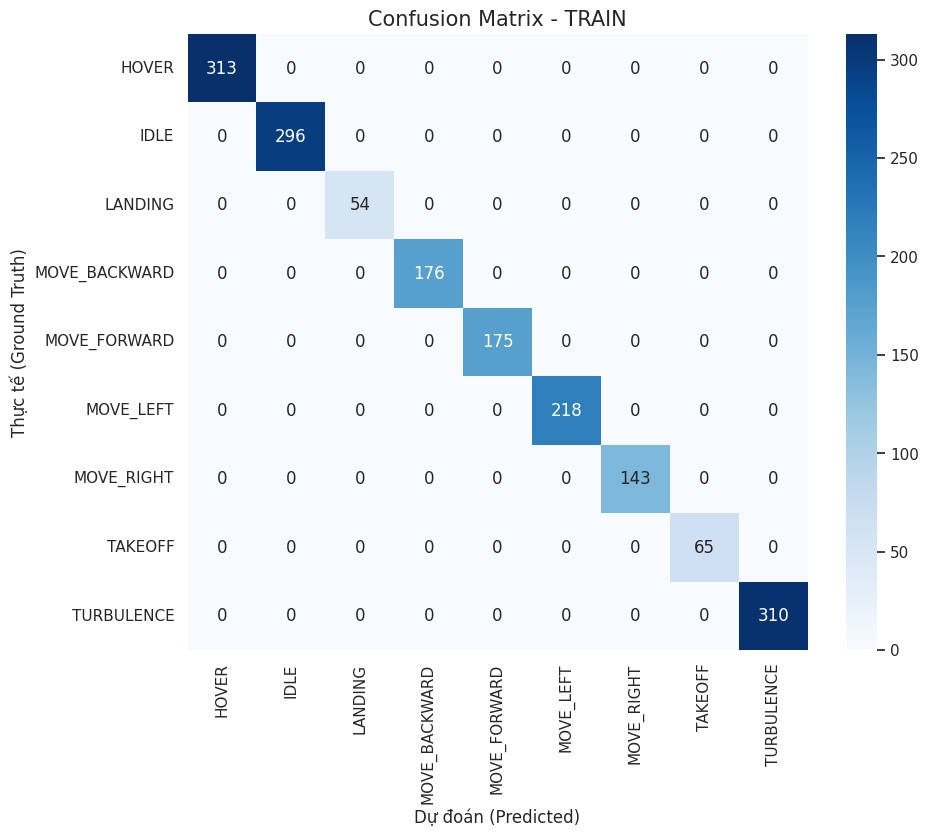


🏆 KẾT QUẢ TRÊN TẬP VAL
🔥 ACCURACY: 92.31%
----------------------------------------
               precision    recall  f1-score   support

        HOVER       0.90      1.00      0.95        27
         IDLE       1.00      1.00      1.00        30
      LANDING       1.00      0.56      0.71         9
MOVE_BACKWARD       1.00      0.80      0.89        10
 MOVE_FORWARD       0.62      1.00      0.76         8
    MOVE_LEFT       0.78      0.78      0.78         9
   MOVE_RIGHT       1.00      0.75      0.86         8
      TAKEOFF       1.00      1.00      1.00         4
   TURBULENCE       1.00      1.00      1.00        25

     accuracy                           0.92       130
    macro avg       0.92      0.88      0.88       130
 weighted avg       0.94      0.92      0.92       130



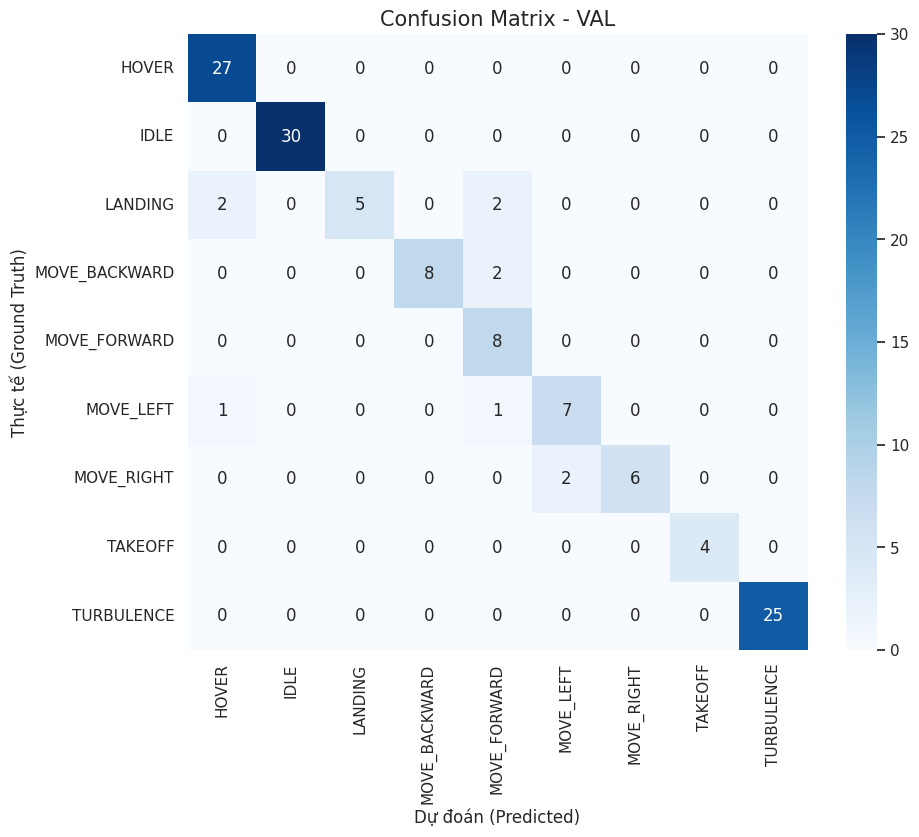

In [4]:
def evaluate_model(model, X, y, dataset_name="TRAIN"):
    if X is None: return

    # Predict
    y_pred = model.predict(X)

    # Metrics
    acc = accuracy_score(y, y_pred)
    print(f"\n{'='*40}")
    print(f"🏆 KẾT QUẢ TRÊN TẬP {dataset_name}")
    print(f"{'='*40}")
    print(f"🔥 ACCURACY: {acc*100:.2f}%")
    print("-"*40)

    # Classification Report (Chi tiết từng nhãn)
    print(classification_report(y, y_pred))

    # Confusion Matrix Visualization
    plt.figure(figsize=(10, 8))
    cm = confusion_matrix(y, y_pred)
    labels = sorted(np.unique(y))

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels)
    plt.title(f'Confusion Matrix - {dataset_name}', fontsize=15)
    plt.xlabel('Dự đoán (Predicted)')
    plt.ylabel('Thực tế (Ground Truth)')
    plt.show()

# 1. Đánh giá trên tập Train (Kỳ vọng ~99-100%)
evaluate_model(rf_model, X_train, y_train, "TRAIN")

# 2. Đánh giá trên tập Val (Kỳ vọng >85-90%)
if X_val is not None:
    evaluate_model(rf_model, X_val, y_val, "VAL")

⏳ Đang tái tạo dòng thời gian chuyến bay...


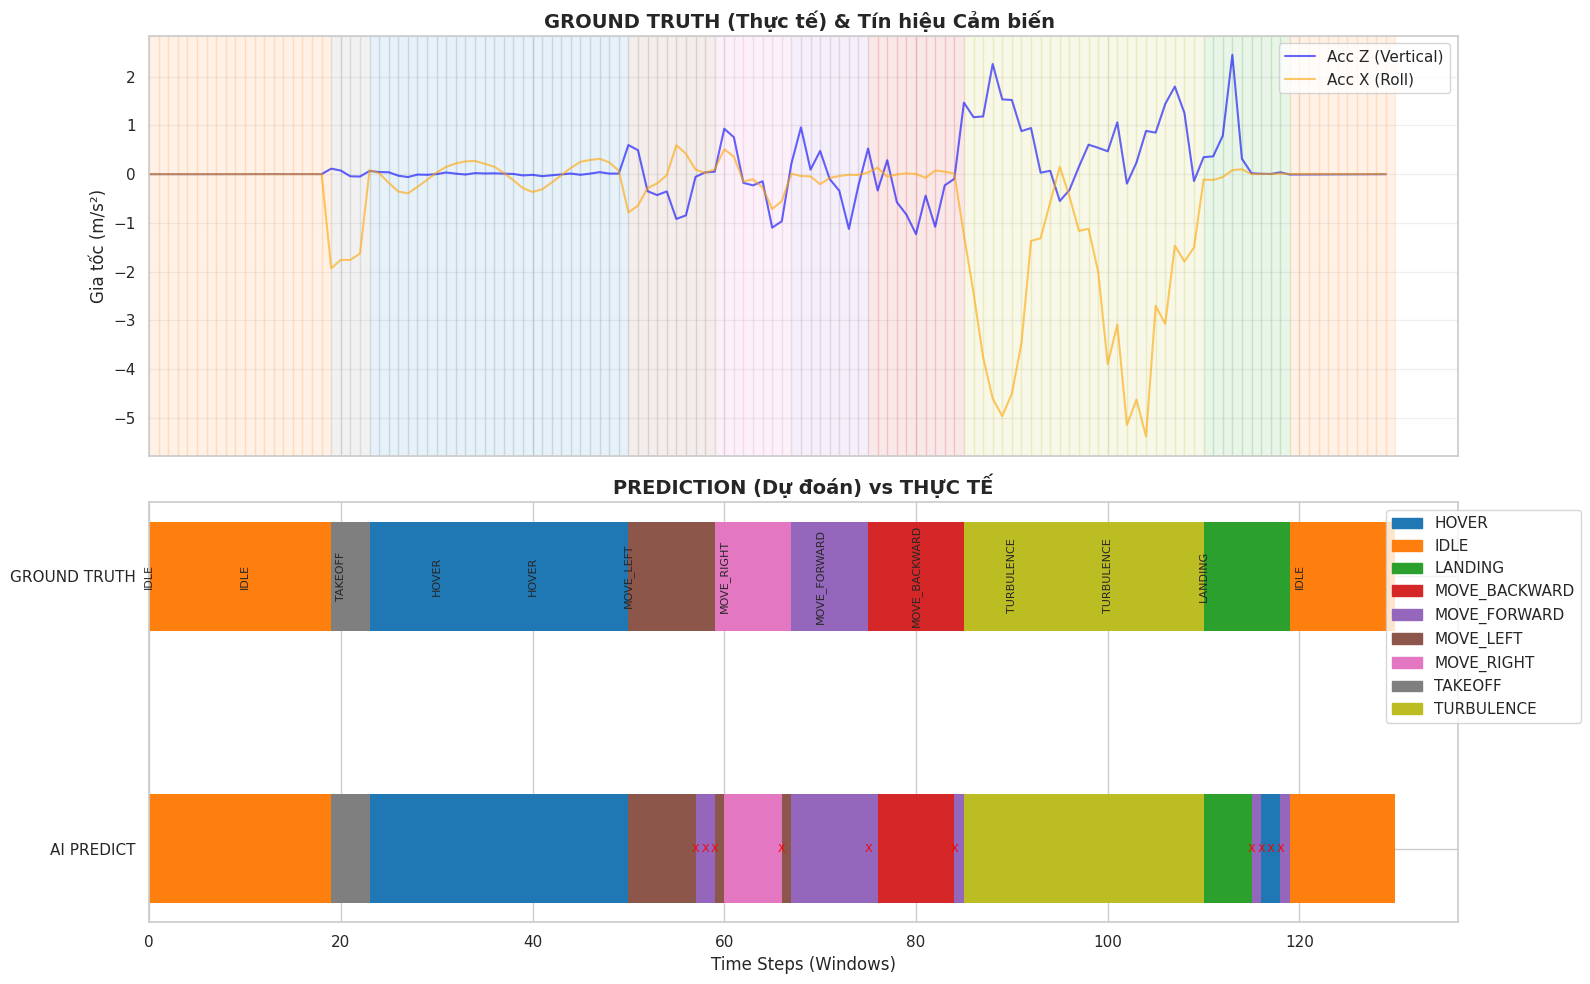

In [5]:
# ==============================================================================
# Ȥ VISUALIZATION: TIMELINE ANALYSIS (GROUND TRUTH vs PREDICTION)
# ==============================================================================
import matplotlib.patches as mpatches
from scipy.stats import linregress, kurtosis, skew

# 1. ĐỊNH NGHĨA LẠI HÀM FEATURE (Để cell này chạy độc lập được)
def extract_feats_debug(window_data):
    """
    Input: window_data (100, 6) -> [acc_x, acc_y, acc_z, gyro_x, gyro_y, gyro_z]
    Output: Dictionary 1 dòng chứa các features
    """
    features = {}
    axis_names = ['acc_x', 'acc_y', 'acc_z', 'gyro_x', 'gyro_y', 'gyro_z']

    for i, axis in enumerate(axis_names):
        signal = window_data[:, i]

        # --- 1. TIME DOMAIN BASIC ---
        features[f'{axis}_mean'] = np.mean(signal)  # Tilt (Góc nghiêng)
        features[f'{axis}_std'] = np.std(signal)    # Vibration (Độ rung)
        features[f'{axis}_max'] = np.max(signal)    # Peak Positive
        features[f'{axis}_min'] = np.min(signal)    # Peak Negative
        features[f'{axis}_range'] = np.max(signal) - np.min(signal)
        features[f'{axis}_rms'] = np.sqrt(np.mean(signal**2))

        # --- 2. IMPACT & SHAPE (Bắt va chạm đùi) ---
        # Kurtosis: Độ nhọn. Landing va chạm -> Spike nhọn -> Kurtosis cao.
        features[f'{axis}_kurtosis'] = kurtosis(signal)

        # Skewness: Độ lệch. Takeoff (vụt lên) lệch dương, Landing (rơi xuống) lệch âm.
        features[f'{axis}_skew'] = skew(signal)

        # --- 3. ᾿ NEW: DYNAMICS & CHAOS (Để bắt Turbulence) ---

        # A. ZERO CROSSING RATE (ZCR)
        # Trừ đi trung bình để đưa tín hiệu về dao động quanh 0
        centered_signal = signal - np.mean(signal)
        # Đếm số lần đổi dấu (cắt qua trục hoành)
        # Takeoff: Thường chỉ cắt 1-2 lần (lên rồi xuống)
        # Turbulence: Cắt liên tục (>10 lần)
        zcr = ((centered_signal[:-1] * centered_signal[1:]) < 0).sum()
        features[f'{axis}_zcr'] = zcr

        # B. JERK (Độ giật - Đạo hàm của gia tốc)
        # Tính sự thay đổi giữa các mẫu liên tiếp
        # Turbulence lắc tay sẽ có độ thay đổi cực gắt
        jerk_signal = np.diff(signal)
        features[f'{axis}_jerk_mean'] = np.mean(np.abs(jerk_signal)) # Trung bình độ giật
        features[f'{axis}_jerk_max']  = np.max(np.abs(jerk_signal))

        # C. Dominant Frequency
        fs = 100 # Assuming 100 samples per second
        fft_vals = np.abs(np.fft.rfft(signal))
        freqs = np.fft.rfftfreq(len(signal), d=1/fs)

        if len(fft_vals) > 1: # check if there are meaningful frequency components
            non_dc_fft_vals = fft_vals[1:]
            non_dc_freqs = freqs[1:]

            if len(non_dc_fft_vals) > 0:
                dominant_freq_idx = np.argmax(non_dc_fft_vals)
                features[f'{axis}_dom_freq'] = non_dc_freqs[dominant_freq_idx]
            else:
                features[f'{axis}_dom_freq'] = 0
        else:
            features[f'{axis}_dom_freq'] = 0

        # --- 4. FREQUENCY DOMAIN (FFT) - Keep these existing ones
        fft_vals_for_energy_max = np.abs(np.fft.rfft(signal))[1:]
        if len(fft_vals_for_energy_max) > 0:
            features[f'{axis}_energy'] = np.sum(fft_vals_for_energy_max**2) / len(fft_vals_for_energy_max)
            features[f'{axis}_fft_max'] = np.max(fft_vals_for_energy_max)
        else:
            features[f'{axis}_energy'] = 0
            features[f'{axis}_fft_max'] = 0

    return features

# 2. LOAD RAW VAL DATA & PREDICT
# Chúng ta load lại file raw để giữ nguyên thứ tự thời gian (Sequence)
val_raw_path = BASE_DIR / 'data/interim/val_raw_clean.csv'
if val_raw_path.exists():
    df_val_raw = pd.read_csv(val_raw_path)

    # Chuẩn bị array để vẽ
    times = []
    acc_z = []
    acc_x = []
    gt_labels = [] # Ground Truth
    pred_labels = [] # Predicted

    # Cấu hình Window như lúc Train
    WIN_SIZE = 100 # 1.0s
    STEP = 20      # 0.2s
    feature_cols = ['acc_x', 'acc_y', 'acc_z', 'gyro_x', 'gyro_y', 'gyro_z']

    # Get the feature names in the correct order from the trained model
    model_feature_names = rf_model.feature_names_in_

    # Duyệt qua từng segment (vì file raw đã được cắt thành segment)
    unique_segments = df_val_raw['unique_seg_id'].unique() if 'unique_seg_id' in df_val_raw else df_val_raw['segment_id'].unique()

    print("⏳ Đang tái tạo dòng thời gian chuyến bay...")

    for seg_id in unique_segments:
        if 'unique_seg_id' in df_val_raw:
            seg_df = df_val_raw[df_val_raw['unique_seg_id'] == seg_id]
        else:
            seg_df = df_val_raw[df_val_raw['segment_id'] == seg_id]

        true_label = seg_df['label'].iloc[0]

        # Sliding window trên segment này
        for i in range(0, len(seg_df) - WIN_SIZE + 1, STEP):
            window = seg_df.iloc[i:i+WIN_SIZE]

            # Lấy data vẽ
            center_idx = i + WIN_SIZE // 2
            times.append(window['time'].iloc[WIN_SIZE//2]) # Lấy time ở giữa
            acc_z.append(window['acc_z'].mean())
            acc_x.append(window['acc_x'].mean())
            gt_labels.append(true_label)

            # Extract Feature & Predict
            feats = extract_feats_debug(window[feature_cols].values)
            feats_df = pd.DataFrame([feats])

            # Reindex columns to match the order expected by the model
            feats_df = feats_df.reindex(columns=model_feature_names, fill_value=0) # Use fill_value=0 if any feature is missing, though it shouldn't be with the current setup

            # Predict
            pred = rf_model.predict(feats_df)[0]
            pred_labels.append(pred)

    # 3. VẼ BIỂU ĐỒ (VISUALIZATION)
    # Tạo màu cho từng nhãn
    unique_lbls = sorted(list(set(gt_labels + pred_labels)))
    palette = sns.color_palette("tab10", len(unique_lbls))
    color_map = {lbl: palette[i] for i, lbl in enumerate(unique_lbls)}

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

    # Chart 1: Ground Truth + Sensor Signals
    ax1.set_title("GROUND TRUTH (Thực tế) & Tín hiệu Cảm biến ", fontsize=14, fontweight='bold')
    ax1.plot(acc_z, label='Acc Z (Vertical)', color='blue', alpha=0.6)
    ax1.plot(acc_x, label='Acc X (Roll)', color='orange', alpha=0.6)
    ax1.set_ylabel("Gia tốc (m/s²)")

    # Tô màu nền theo Ground Truth
    for i in range(len(gt_labels)):
        ax1.axvspan(i, i+1, color=color_map[gt_labels[i]], alpha=0.1) # Màu nhạt

    ax1.legend(loc='upper right')
    ax1.grid(True, alpha=0.3)

    # Chart 2: Prediction vs Ground Truth Blocks
    ax2.set_title("PREDICTION (Dự đoán) vs THỰC TẾ", fontsize=14, fontweight='bold')

    # Vẽ Ground Truth Bar (Hàng trên)
    for i in range(len(gt_labels)):
        ax2.barh(1, 1, left=i, color=color_map[gt_labels[i]], edgecolor='none', height=0.4)
        if i % 10 == 0: # Ghi nhãn định kỳ
             ax2.text(i, 1, gt_labels[i], fontsize=8, rotation=90, va='center', ha='center')

    # Vẽ Prediction Bar (Hàng dưới)
    for i in range(len(pred_labels)):
        ax2.barh(0, 1, left=i, color=color_map[pred_labels[i]], edgecolor='none', height=0.4)
        if pred_labels[i] != gt_labels[i]: # Đánh dấu chỗ sai
             ax2.text(i, 0, "X", fontsize=8, va='center', ha='center', color='red') # Changed '❌' to 'X'

    ax2.set_yticks([0, 1])
    ax2.set_yticklabels(['AI PREDICT', 'GROUND TRUTH'])
    ax2.set_xlabel("Time Steps (Windows)")

    # Legend Labels
    patches = [mpatches.Patch(color=color_map[l], label=l) for l in unique_lbls]
    ax2.legend(handles=patches, loc='upper right', bbox_to_anchor=(1.1, 1))

    plt.tight_layout()
    plt.show()

else:
    print("❌ Không tìm thấy file val_raw_clean.csv")

## 💾 4. SAVE MODEL
Lưu lại model để dùng cho bước suy luận thực tế (Inference).

In [6]:
save_path = MODELS_DIR / 'rf_model.joblib'
joblib.dump(rf_model, save_path)

print(f"✅ Đã lưu model tại: {save_path}")
print("Sẵn sàng cho Notebook 06 (Feature Analysis) và Inference!")

✅ Đã lưu model tại: /content/drive/MyDrive/Drone_Project_2025/models/rf_model.joblib
Sẵn sàng cho Notebook 06 (Feature Analysis) và Inference!


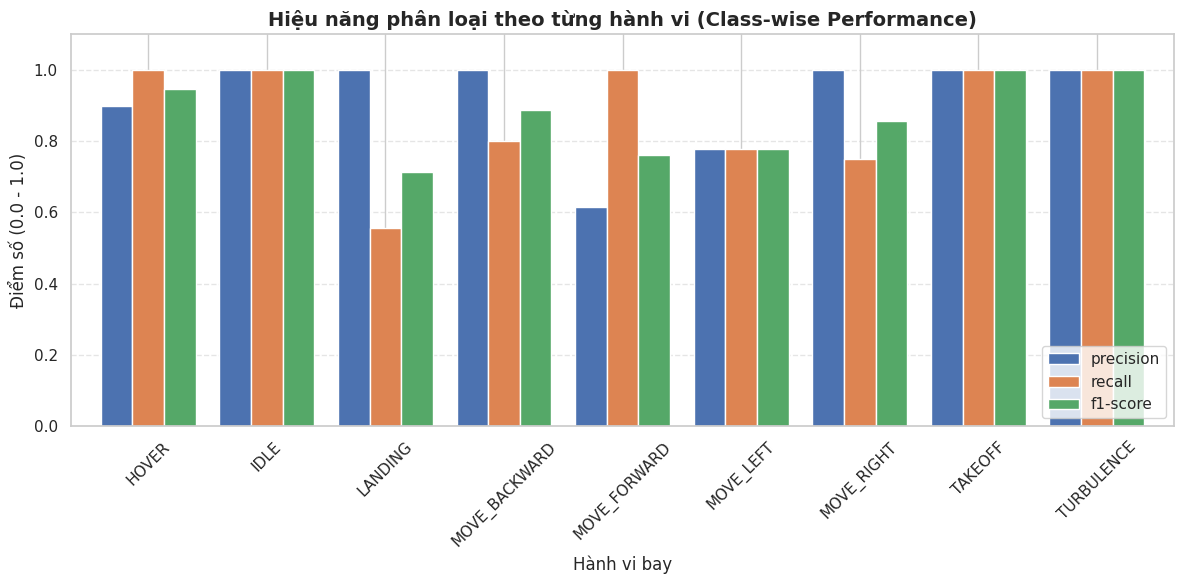

In [7]:
# --- CODE VẼ HÌNH 5.1: CLASS-WISE PERFORMANCE ---
from sklearn.metrics import classification_report

def plot_class_performance(y_true, y_pred):
    # Lấy report dưới dạng dict
    report = classification_report(y_true, y_pred, output_dict=True)

    # Chuyển thành DataFrame, bỏ dòng 'accuracy', 'macro avg', 'weighted avg'
    metrics_df = pd.DataFrame(report).transpose()
    classes = [idx for idx in metrics_df.index if idx not in ['accuracy', 'macro avg', 'weighted avg']]
    metrics_df = metrics_df.loc[classes]

    # Vẽ biểu đồ
    metrics_df[['precision', 'recall', 'f1-score']].plot(kind='bar', figsize=(12, 6), width=0.8)

    plt.title('Hiệu năng phân loại theo từng hành vi (Class-wise Performance)', fontsize=14, fontweight='bold')
    plt.ylabel('Điểm số (0.0 - 1.0)')
    plt.xlabel('Hành vi bay')
    plt.ylim(0, 1.1)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.legend(loc='lower right')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Gọi hàm (Chạy sau khi đã train và predict ở Notebook 05 hoặc 09)
if 'y_val' in locals() and 'rf_model' in locals():
    y_val_pred = rf_model.predict(X_val) # Hoặc dùng X_train/y_train nếu muốn xem train
    plot_class_performance(y_val, y_val_pred)


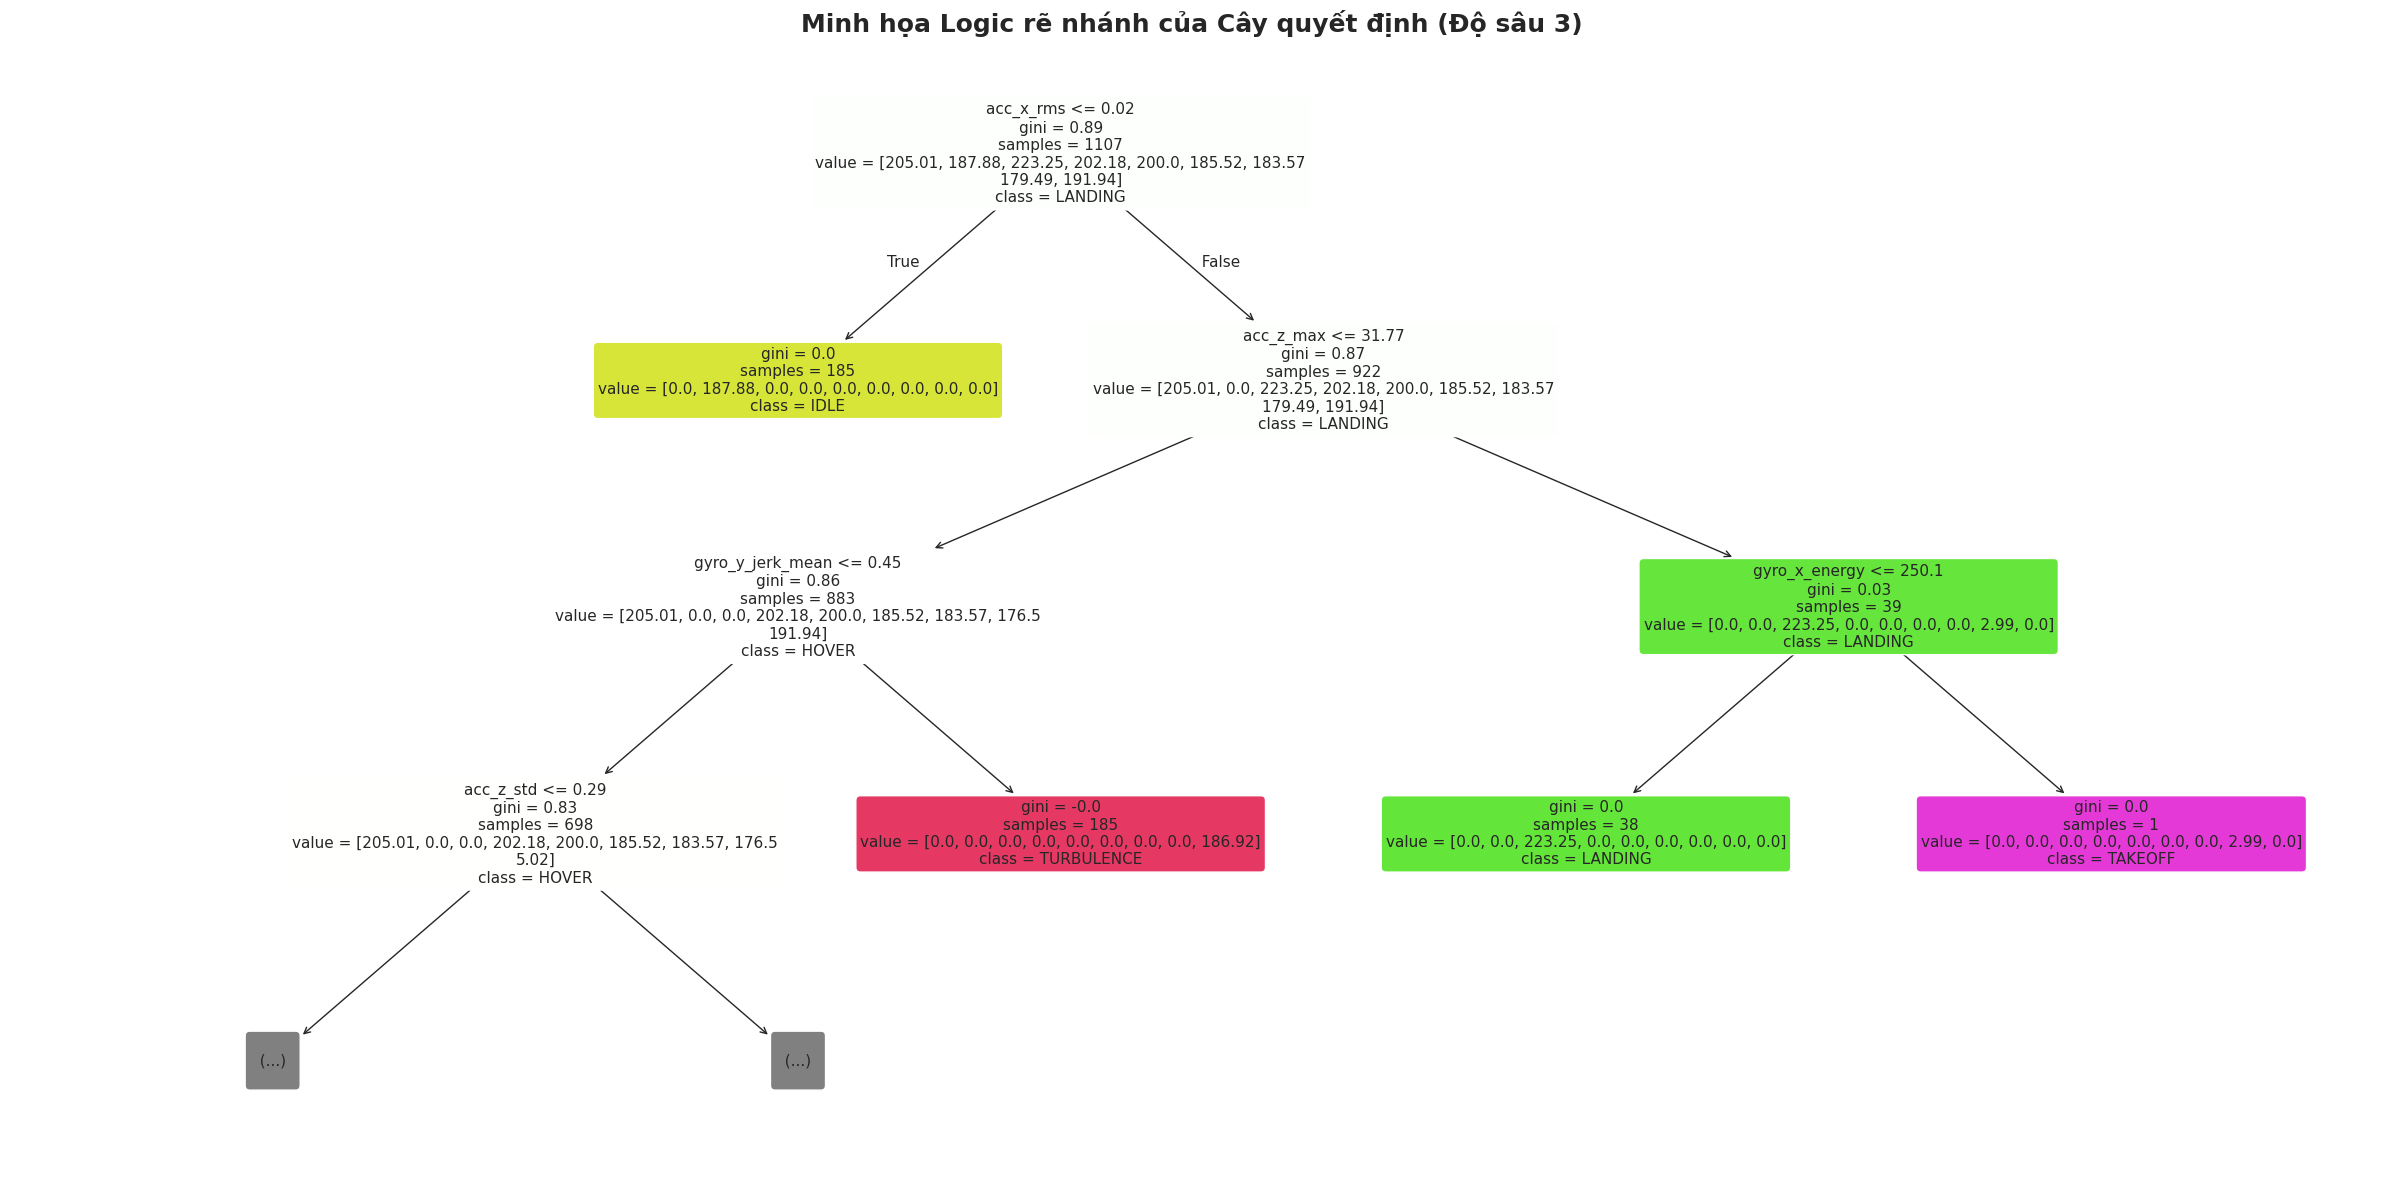

✅ Đã lưu ảnh 'decision_tree_viz.png'.
💡 Hướng dẫn đọc: Nút gốc (Root) là đặc trưng quan trọng nhất để phân loại.


In [8]:
# ==============================================================================
# 🌳 TRỰC QUAN HÓA CẤU TRÚC CÂY QUYẾT ĐỊNH (DECISION TREE VISUALIZER)
# ==============================================================================
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

def visualize_single_tree(model, depth=3):
    """
    Vẽ 1 cây trong rừng để minh họa logic.
    depth: Độ sâu hiển thị (nên để 3-4 để còn đọc được chữ, để None sẽ bị rối)
    """
    # 1. Lấy cây đầu tiên ra (Estimator 0)
    estimator = model.estimators_[0]

    # 2. Lấy tên Features và Class
    feature_names = model.feature_names_in_
    class_names = model.classes_

    # 3. Vẽ hình
    plt.figure(figsize=(24, 12)) # Kích thước lớn để rõ chữ

    plot_tree(estimator,
              max_depth=depth,         # Chỉ vẽ 3 tầng đầu tiên
              feature_names=feature_names,
              class_names=class_names,
              filled=True,             # Tô màu theo lớp
              rounded=True,            # Bo tròn góc cho đẹp
              precision=2,             # Số thập phân
              fontsize=11)

    plt.title(f"Minh họa Logic rẽ nhánh của Cây quyết định (Độ sâu {depth})", fontsize=18, fontweight='bold')
    plt.tight_layout()
    plt.savefig('decision_tree_viz.png', dpi=300) # Lưu ảnh nét cao
    plt.show()

    print("✅ Đã lưu ảnh 'decision_tree_viz.png'.")
    print("💡 Hướng dẫn đọc: Nút gốc (Root) là đặc trưng quan trọng nhất để phân loại.")

# Gọi hàm (Yêu cầu rf_model đã được load/train)
if 'rf_model' in locals():
    visualize_single_tree(rf_model, depth=3)
elif 'rf_full' in locals():
    visualize_single_tree(rf_full, depth=3)
else:
    print("⚠️ Hãy load model (rf_model) trước!")